In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/crimes.csv.csv')

In [ ]:
df

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,221412410,2022-06-15,2020-11-12,1700,Pacific,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),0.0,NaN,NaN,NaN,Invest Cont,13600 MARINA POINT DR
1,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27.0,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
2,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60.0,M,H,NaN,Invest Cont,3300 SAN MARINO ST
3,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28.0,M,H,NaN,Invest Cont,1900 TRANSIENT
4,231207725,2023-02-27,2020-01-27,635,77th Street,THEFT OF IDENTITY,37.0,M,H,NaN,Invest Cont,6200 4TH AV
...,...,...,...,...,...,...,...,...,...,...,...,...
43694,220619579,2022-11-26,2022-11-26,1300,Hollywood,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",23.0,F,W,NaN,Invest Cont,1900 N CURSON AV
43695,222018206,2022-12-08,2022-12-08,505,Olympic,BURGLARY,0.0,X,X,NaN,Invest Cont,200 N WESTERN AV
43696,220416237,2022-12-11,2022-12-11,2020,Hollenbeck,ROBBERY,0.0,X,X,UNKNOWN WEAPON/OTHER WEAPON,Invest Cont,4800 VALLEY BL
43697,220125529,2022-12-01,2022-12-01,735,Central,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",28.0,M,B,SCISSORS,Adult Arrest,600 S BROADWAY


In [ ]:
# peak crime hour
# عندي مشكله فال time occ

In [ ]:
df['Hour'] = df['TIME OCC'] // 100

In [ ]:
df[['TIME OCC', 'Hour']].head(10)

,TIME OCC,Hour
0,1700,17
1,1110,11
2,1620,16
3,1200,12
4,635,6
5,900,9
6,1000,10
7,1200,12
8,1335,13
9,1,0


In [ ]:
peak_crime_hour = df['Hour'].value_counts().idxmax()

print(peak_crime_hour)

12


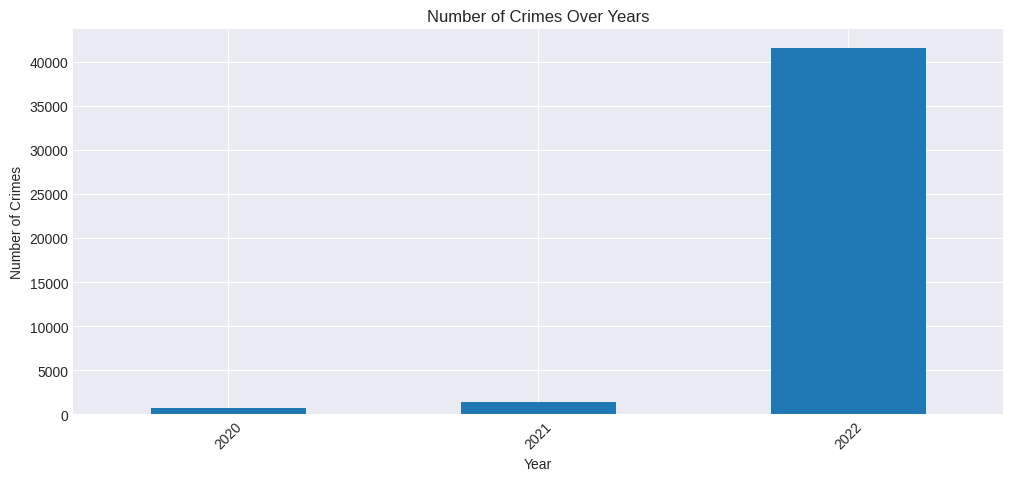

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12,5))
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'])
df['DATE OCC'].dt.year.value_counts().sort_index().plot(kind='bar')
plt.title('Number of Crimes Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# night crime

In [ ]:
night_crimes = df[(df['Hour'] >= 22) | (df['Hour'] <= 4)]

In [ ]:
df.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA NAME',
       'Crm Cd Desc', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Weapon Desc',
       'Status Desc', 'LOCATION', 'Hour'],
      dtype='object')

In [ ]:
# هنحسب عدد الجرائم فكل area

In [ ]:
area_crimes = night_crimes['AREA NAME'].value_counts()

In [ ]:
# هنجيب ال area الاعلي

In [ ]:
peak_night_area = area_crimes.idxmax()
print(peak_night_area )

Central


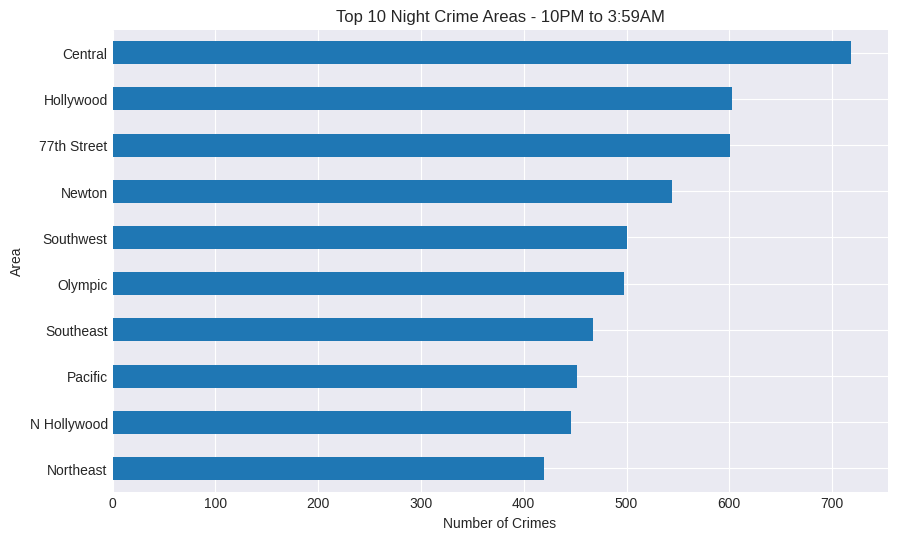

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
night_df = df[(df['Hour'] >= 22) | (df['Hour'] <= 3)]
top_areas = night_df['AREA NAME'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_areas.plot(kind='barh')
plt.title('Top 10 Night Crime Areas - 10PM to 3:59AM')
plt.xlabel('Number of Crimes')
plt.ylabel('Area')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# victim Demographics

In [ ]:
age_bins = [0,17,25,34,44,54,64, float('inf')]

In [ ]:
# هسمي الفئات

In [ ]:
age_labels = ['0-17','18-25','26-34','35-44','45-54','55-64','65+']

In [ ]:
#هقسم فئات

In [ ]:
age_groups = pd.cut(df['Vict Age'], bins=age_bins, labels=age_labels)

In [ ]:
# هحسب عدد الجرائم في كل فئه

In [ ]:
victim_ages = age_groups.value_counts().sort_index()

In [ ]:
victim_ages

,count
Vict Age,
0-17,811
18-25,5068
26-34,8470
35-44,7664
45-54,5119
55-64,3740
65+,2591


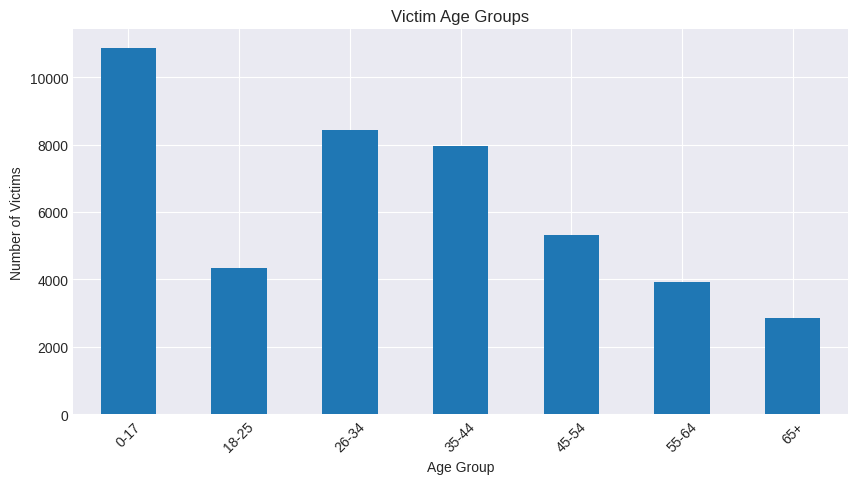

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
bins = [0, 17, 25, 34, 44, 54, 64, 100]
labels = ['0-17', '18-25', '26-34', '35-44', '45-54', '55-64', '65+']
df['Age Group'] = pd.cut(df['Vict Age'], bins=bins, labels=labels, right=False)
age_group_counts = df['Age Group'].value_counts().sort_index()

plt.figure(figsize=(10,5))
age_group_counts.plot(kind='bar')
plt.title('Victim Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Victims')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# anomaly detection
# هنستخدم vict age
#  هنحسب الربع الاول والتالت

In [ ]:
Q1 = df['Vict Age'].quantile(0.25)
Q3 = df['Vict Age'].quantile(0.75)
print(Q3)

45.0


In [ ]:
#هنحسب IQR

In [ ]:
IQR = Q3 - Q1
print(IQR)

28.0


In [ ]:
Lower_bound = Q1 - 1.5 * IQR
print(Lower_bound)

-25.0


In [ ]:
Upper_bound = Q3 + 1.5 * IQR
print(Upper_bound)

87.0


In [ ]:
outliers = df[(df['Vict Age'] < Lower_bound) | (df['Vict Age'] > Upper_bound)]
outliers['Vict Age']

,Vict Age
526,90.0
1162,89.0
1194,98.0
1363,93.0
1647,88.0
...,...
40727,88.0
41127,98.0
41232,93.0
41539,96.0


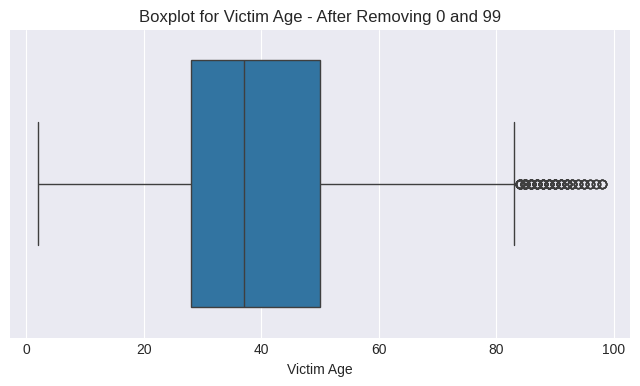

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
df_clean = df[(df['Vict Age'] > 0) & (df['Vict Age'] < 99)]

plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean['Vict Age'])
plt.title('Boxplot for Victim Age - After Removing 0 and 99')
plt.xlabel('Victim Age')
plt.show()

In [ ]:
#the most common crime type

In [ ]:
df['Crm Cd Desc'].value_counts().idxmax()

'THEFT OF IDENTITY'

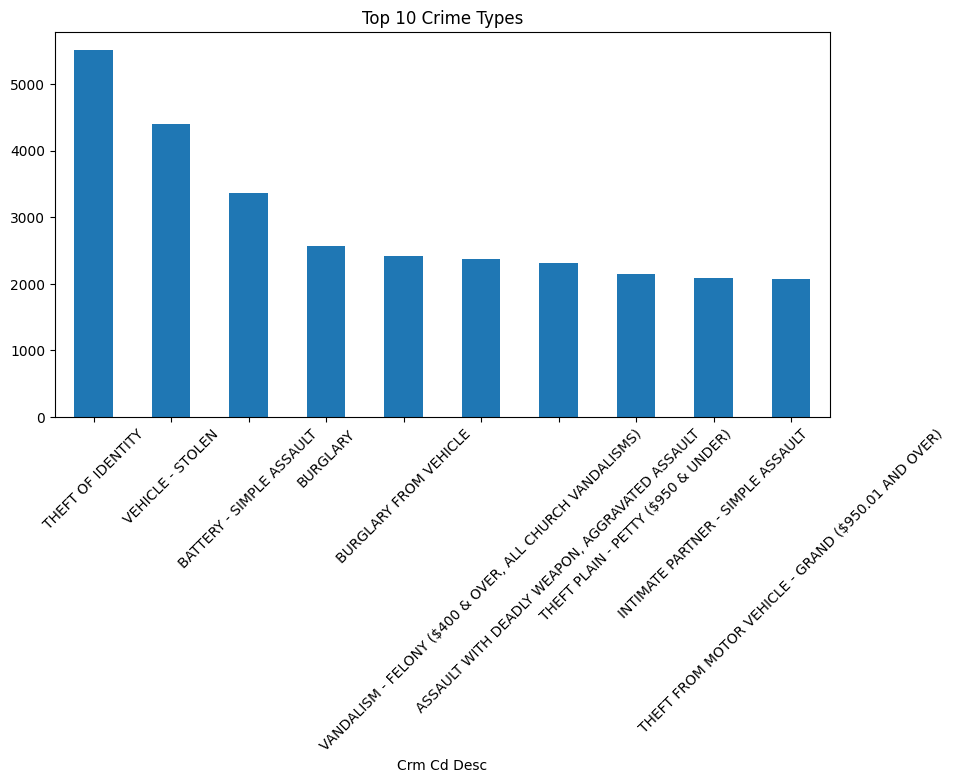

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
crime_counts = df['Crm Cd Desc'].value_counts().head(10)
plt.figure(figsize=(10,5))
crime_counts.plot(kind='bar')
plt.title('Top 10 Crime Types')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#which gender is the most common among crime victims?

In [ ]:
df['Vict Sex'].value_counts().idxmax()

'M'

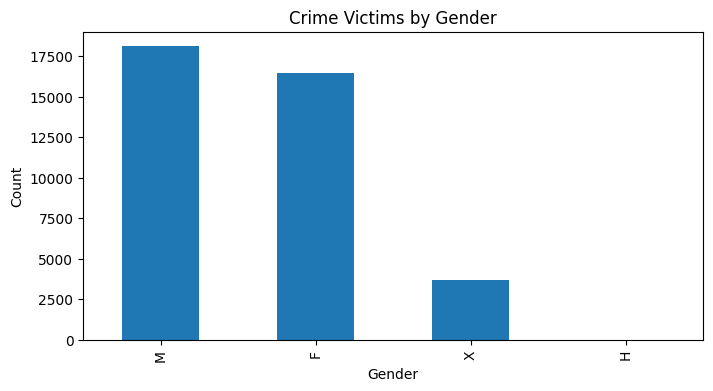

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
gender_counts = df['Vict Sex'].value_counts()
plt.figure(figsize=(8,4))
gender_counts.plot(kind='bar')
plt.title('Crime Victims by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()